In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv(r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\insurance.csv')

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


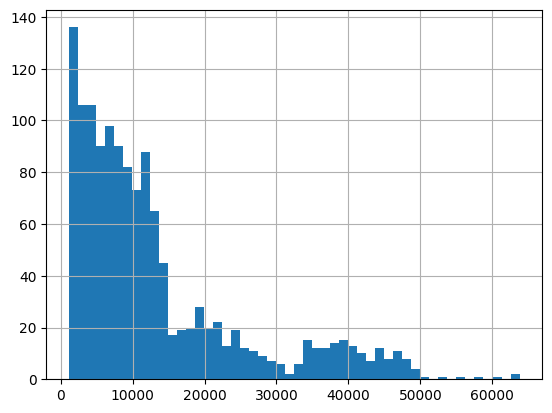

In [7]:
df['charges'].hist(bins=50);

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

X = df.drop("charges", axis=1)
y = df["charges"]

y = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(alpha=1.0))
])

pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
from sklearn.metrics import mean_squared_error

pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

RMSE: 0.4190168541810641


In [10]:
pred_real = np.expm1(pred)
y_test_real = np.expm1(y_test)

In [11]:
pred_real, y_test_real

(array([ 9089.39360191,  5606.81781822, 65769.15161747,  9126.84667347,
        14034.7786963 ,  5948.65656835,  2830.505004  , 15103.08553442,
         3794.96124214, 10525.90538346, 22803.91885629,  7490.39093995,
         4446.11944791, 49639.46792687, 59562.50812646, 44713.83886397,
        11546.36167356, 42539.81003209,  7788.28858304, 32070.00515699,
         4887.94944385,  7717.46043724,  2739.52762982,  4196.79840541,
        11637.41336671, 11382.90637478, 12782.2667212 ,  5465.64905952,
         9923.19408666,  2603.44296409,  8625.78953271, 11784.77331591,
         3312.44350847,  5254.75160502,  3797.11378237,  8560.34027115,
         3281.22050101,  7303.39263268, 46094.68102827, 26599.0769917 ,
         4569.09144507,  3602.41672615, 12343.6834439 , 10749.13895121,
         5646.40526353, 11348.43666109,  4240.65245299,  4398.8199929 ,
        41079.90455084,  5465.58777929, 14207.48779643,  2825.79211556,
         8232.37432172,  2822.62199599, 10125.09520552, 11005.68

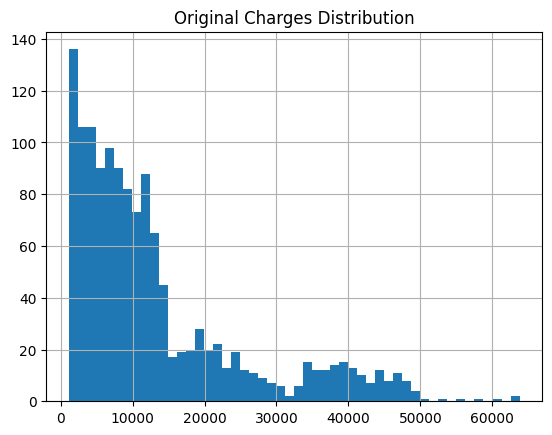

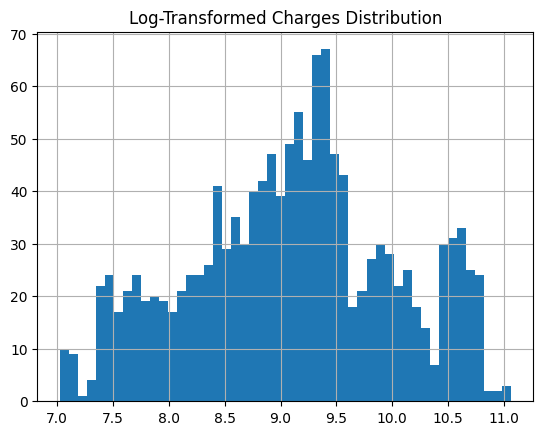

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
df["charges"].hist(bins=50)
plt.title("Original Charges Distribution")

plt.figure()
np.log1p(df["charges"]).hist(bins=50)
plt.title("Log-Transformed Charges Distribution")
plt.show()